# Notebook 04 — DeBERTa-v3-base Training

## AI-Based Toxicity Detection using Transformer Models

This notebook fine-tunes **Microsoft DeBERTa-v3-base** for binary toxicity classification using the balanced 80,000/20,000 train/validation split produced in Notebook 03.

### Objectives
- Load the train/validation Parquet files produced by Notebook 03.
- Tokenize the text using the DeBERTa-v3-base tokenizer.
- Fine-tune DeBERTa-v3-base on the Kaggle GPU environment.
- Preserve the 80,000 training / 20,000 validation methodology.
- Select the best model using validation F1-score.
- Evaluate the final model with multiple metrics.
- Save the trained model, tokenizer, predictions, reports, and figures.

### Model
**microsoft/DeBERTa-v3-base**

### Dataset
- Training: 80,000 examples (40,000 non-toxic / 40,000 toxic)
- Validation: 20,000 examples (10,000 non-toxic / 10,000 toxic)

The Parquet files contain the preprocessed text (`clean_text`) and label (`is_toxic`). Notebook 04 tokenizes this text using the DeBERTa-v3-base tokenizer, with a maximum sequence length of 384 tokens.

### Runtime
This version is configured for **Kaggle GPU** training. It automatically detects the available CUDA GPUs and enables FP16 when CUDA is available. The intended effective global batch size remains 16.


# Import Required Libraries

Most of the notebook's imports are collected in one place. This covers:

- Data handling
- Deep learning (PyTorch)
- Hugging Face `datasets` / `transformers`
- Evaluation metrics
- Visualization
- Model / artifact saving

A few small, standard-library imports (e.g. `inspect`) are added later, right where they are used, for runtime version-compatibility checks.


In [1]:
import os

# Kaggle T4 x2: force single-GPU execution.
# Trainer falls back to naive nn.DataParallel when it sees >1 GPU in a plain
# notebook (no torchrun/accelerate launch), and DataParallel + fp16
# (GradScaler) is broken in current transformers/accelerate -- it raises
# 'ValueError: Attempting to unscale FP16 gradients.' during backward.
# Pinning to one GPU avoids DataParallel entirely and fixes this.
# Must be set before torch is imported/initializes any CUDA context.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")


Libraries imported successfully.


# Reproducibility

To ensure identical results across multiple runs, a fixed random seed is used for:

- Python's `random` module
- NumPy
- PyTorch


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random Seed:", SEED)


Random Seed: 42


# Configuration

All project paths, model settings, and output directories are defined here.

The input paths below are the **Kaggle dataset mount paths**. The output directory is writable Kaggle storage.

Text is tokenized in this notebook using a maximum sequence length of 384 tokens.


In [3]:
MODEL_NAME = "microsoft/deberta-v3-base"

# Kaggle input dataset
DATA_DIR = Path("../Dataset/processed/train_valid_split")
TRAIN_PATH = DATA_DIR / "train.parquet"
VALID_PATH = DATA_DIR / "valid.parquet"

# Kaggle writable output directory
OUTPUT_DIR = Path("../models/deberta_v3_base")
FIGURE_DIR = OUTPUT_DIR / "figures"
REPORT_DIR = OUTPUT_DIR / "reports"
PREDICTION_DIR = OUTPUT_DIR / "predictions"

for folder in [OUTPUT_DIR, FIGURE_DIR, REPORT_DIR, PREDICTION_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

MAX_LENGTH = 384

print("Configuration loaded.")
print(f"Model: {MODEL_NAME}")
print(f"Training dataset : {TRAIN_PATH}")
print(f"Validation dataset: {VALID_PATH}")
print(f"Output directory : {OUTPUT_DIR}")
print(f"Max sequence length: {MAX_LENGTH}")


Configuration loaded.
Model: microsoft/deberta-v3-base
Training dataset : /kaggle/input/datasets/tzmughal/toxicity-social-dataset/train.parquet
Validation dataset: /kaggle/input/datasets/tzmughal/toxicity-social-dataset/valid.parquet
Output directory : /kaggle/working/deberta_v3_base
Max sequence length: 384


# Verify Dataset Availability

Confirm that the Kaggle-mounted train and validation Parquet files exist before loading them.


In [4]:
assert TRAIN_PATH.exists(), f"Missing training file: {TRAIN_PATH}"
assert VALID_PATH.exists(), f"Missing validation file: {VALID_PATH}"

print("Training dataset found:", TRAIN_PATH)
print("Validation dataset found:", VALID_PATH)


Training dataset found: /kaggle/input/datasets/tzmughal/toxicity-social-dataset/train.parquet
Validation dataset found: /kaggle/input/datasets/tzmughal/toxicity-social-dataset/valid.parquet


# Load Training and Validation Datasets

The Parquet files produced by Notebook 03 are loaded directly with Hugging Face `datasets`.

They already contain the final 80,000/20,000 split, so there is no pandas filtering or rebalancing. The text still needs to be tokenized, which happens later in this notebook.


In [5]:
dataset = load_dataset(
    "parquet",
    data_files={
        "train": str(TRAIN_PATH),
        "validation": str(VALID_PATH),
    },
)

train_dataset = dataset["train"]
valid_dataset = dataset["validation"]

print(train_dataset)
print(valid_dataset)

print(f"Training examples   : {len(train_dataset):,}")
print(f"Validation examples : {len(valid_dataset):,}")


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['clean_text', 'is_toxic'],
    num_rows: 80000
})
Dataset({
    features: ['clean_text', 'is_toxic'],
    num_rows: 20000
})
Training examples   : 80,000
Validation examples : 20,000


# Load DeBERTa-v3-base Tokenizer

The tokenizer is loaded here so it is available for tokenizing the text in the next step, and so it can be saved alongside the trained model.


In [6]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False,
)

print("Tokenizer:", type(tokenizer).__name__)
print("Vocabulary size:", tokenizer.vocab_size)


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Tokenizer: DebertaV2Tokenizer
Vocabulary size: 128000


# Tokenization





Expected columns:
- `label`
- `input_ids`
- `token_type_ids`
- `attention_mask`


In [7]:
# ============================================================
# TOKENIZE TRAINING AND VALIDATION DATASETS
# ============================================================

print("=" * 70)
print("TOKENIZING DATASETS")
print("=" * 70)

print(f"Maximum sequence length: {MAX_LENGTH}")

def tokenize_function(batch):
    """
    Tokenize preprocessed text and convert the toxicity
    target into the Hugging Face `labels` field.
    """

    tokenized = tokenizer(
        batch["clean_text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

    tokenized["labels"] = batch["is_toxic"]

    return tokenized


# ------------------------------------------------------------
# Tokenize training dataset
# ------------------------------------------------------------

print("\nTokenizing training dataset...")

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    remove_columns=train_dataset.column_names,
    desc="Training Tokenization",
)

print("Training tokenization completed.")


# ------------------------------------------------------------
# Tokenize validation dataset
# ------------------------------------------------------------

print("\nTokenizing validation dataset...")

valid_dataset = valid_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    remove_columns=valid_dataset.column_names,
    desc="Validation Tokenization",
)

print("Validation tokenization completed.")


print("\n" + "=" * 70)
print("TOKENIZATION COMPLETED")
print("=" * 70)

print("\nTraining dataset:")
print(train_dataset)

print("\nValidation dataset:")
print(valid_dataset)

TOKENIZING DATASETS
Maximum sequence length: 384

Tokenizing training dataset...


Training Tokenization:   0%|          | 0/80000 [00:00<?, ? examples/s]

Training tokenization completed.

Tokenizing validation dataset...


Validation Tokenization:   0%|          | 0/20000 [00:00<?, ? examples/s]

Validation tokenization completed.

TOKENIZATION COMPLETED

Training dataset:
Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 80000
})

Validation dataset:
Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 20000
})


In [8]:
# ============================================================
# VERIFY TOKENIZED DATASETS
# ============================================================

print("=" * 70)
print("VERIFYING TOKENIZED DATASETS")
print("=" * 70)

required_columns = {
    "input_ids",
    "attention_mask",
    "labels",
}

missing_train = required_columns - set(train_dataset.column_names)
missing_valid = required_columns - set(valid_dataset.column_names)

assert not missing_train, (
    f"Missing training columns: {missing_train}"
)

assert not missing_valid, (
    f"Missing validation columns: {missing_valid}"
)

assert len(train_dataset) == 80_000
assert len(valid_dataset) == 20_000

print("\nTraining examples   :", f"{len(train_dataset):,}")
print("Validation examples :", f"{len(valid_dataset):,}")

print("\nTraining columns:")
print(train_dataset.column_names)

print("\nValidation columns:")
print(valid_dataset.column_names)

print("\nFirst training record:")
print(train_dataset[0])

print("\n" + "=" * 70)
print("TOKENIZED DATASET CHECK PASSED")
print("=" * 70)

VERIFYING TOKENIZED DATASETS

Training examples   : 80,000
Validation examples : 20,000

Training columns:
['input_ids', 'token_type_ids', 'attention_mask', 'labels']

Validation columns:
['input_ids', 'token_type_ids', 'attention_mask', 'labels']

First training record:
{'input_ids': [266, 7478, 71174, 1182, 3389, 1196, 404, 388, 824, 263, 278, 284, 539, 260, 386, 7708, 261, 3092, 261, 904, 355, 464, 308, 451, 677, 277, 2905, 5782, 808, 260, 347, 681, 1951, 265, 262, 484, 5902, 1619, 293, 262, 4637, 8795, 263, 8566, 1411, 396, 277, 262, 703, 280, 293, 703, 280, 6520, 14226, 560, 277, 947, 1253, 292, 3385, 22581, 289, 48415, 260, 306, 3115, 275, 3092, 263, 7708, 3959, 328, 330, 426, 1936, 270, 478, 3051, 1146, 2497, 401, 308, 1549, 2464, 266, 4319, 557, 300, 266, 467, 1355, 1196, 264, 9304, 880, 3092, 355, 328, 330, 331, 2697, 260, 2275, 261, 262, 28831, 1528, 284, 50000, 6824, 288, 262, 9199, 3962, 265, 7478, 71174, 260, 337, 274, 281, 298, 266, 904, 9664, 5799, 277, 5970, 8403, 261, 

# Dynamic Padding (Data Collator)

Dynamic padding pads each batch only to the longest sequence in that batch, reducing unnecessary computation compared with padding every example to 384 tokens.


In [9]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
)

print("Data collator created.")


Data collator created.


# Load DeBERTa-v3-base

A binary classification head is added automatically.

Labels:
- `0` → Non-toxic
- `1` → Toxic

The model architecture and pretrained weights are unchanged.


In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

# Recent transformers versions default to loading weights in whatever dtype
# the checkpoint was saved in (which can be fp16) instead of always fp32.
# Trainer's fp16=True mixed precision (GradScaler) requires fp32 master
# weights -- it refuses to unscale gradients that are already fp16, which is
# exactly the "Attempting to unscale FP16 gradients" error. Force fp32
# explicitly here regardless of what from_pretrained chose, so autocast can
# safely produce fp16 activations during the forward pass while the actual
# weights/gradients stay fp32.
model = model.float()
print("Model parameter dtype:", next(model.parameters()).dtype)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias          

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Model parameter dtype: torch.float32
Total parameters     : 184,423,682
Trainable parameters : 184,423,682


# Evaluation Metrics

The primary metric for model/checkpoint selection is **F1-score**, since toxicity classification is sensitive to class distribution even when the training set itself is balanced.

Metrics computed at every evaluation:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC


In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Numerically stable softmax
    probabilities = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probabilities = probabilities / probabilities.sum(axis=1, keepdims=True)

    predictions = np.argmax(probabilities, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0,
    )

    accuracy = accuracy_score(labels, predictions)

    try:
        roc_auc = roc_auc_score(labels, probabilities[:, 1])
    except ValueError:
        roc_auc = 0.0

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
    }


print("Evaluation metrics function ready.")


Evaluation metrics function ready.


# Training Configuration — Kaggle GPU


This notebook pins execution to a single visible GPU (see the import cell), so the physical batch size is selected for one T4 GPU and the gradient accumulation is calculated so that the **effective global batch size remains approximately 16**.

FP16 is enabled only when CUDA is available.


In [12]:
GPU_COUNT = max(1, torch.cuda.device_count())

EPOCHS = 4
LEARNING_RATE = 2e-5
BATCH_SIZE = 8
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
LOGGING_STEPS = 100

# Keep the intended global effective batch size near 16.
GRADIENT_ACCUMULATION_STEPS = max(
    1,
    int(np.ceil(16 / (BATCH_SIZE * GPU_COUNT)))
)

EFFECTIVE_BATCH_SIZE = BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS * GPU_COUNT

print("Training configuration:")
print(f"CUDA available              : {torch.cuda.is_available()}")
print(f"GPU count                   : {GPU_COUNT}")
if torch.cuda.is_available():
    for i in range(GPU_COUNT):
        print(f"GPU {i}                      : {torch.cuda.get_device_name(i)}")
print(f"Epochs                      : {EPOCHS}")
print(f"Learning rate               : {LEARNING_RATE}")
print(f"Per-GPU batch size          : {BATCH_SIZE}")
print(f"Gradient accumulation steps : {GRADIENT_ACCUMULATION_STEPS}")
print(f"Effective global batch size : {EFFECTIVE_BATCH_SIZE}")
print(f"Max sequence length        : {MAX_LENGTH}")


Training configuration:
CUDA available              : True
GPU count                   : 1
GPU 0                      : Tesla T4
Epochs                      : 4
Learning rate               : 2e-05
Per-GPU batch size          : 8
Gradient accumulation steps : 2
Effective global batch size : 16
Max sequence length        : 384


# Hugging Face Training Arguments

This configuration is designed for Kaggle GPU execution:

- FP16 is enabled on CUDA/T4 GPUs.
- CPU-only fallback remains possible.
- Data-loader workers are enabled for Kaggle Linux.
- Pinned memory is enabled for CUDA transfers.
- Evaluation and checkpointing occur once per epoch.
- Only one checkpoint is retained.
- No `overwrite_output_dir` argument is used because it is not accepted by the installed Transformers 5.x API.
- The code detects whether the installed version uses `eval_strategy` or the older `evaluation_strategy` name.


In [13]:
import inspect

ta_params = inspect.signature(TrainingArguments.__init__).parameters

training_kwargs = dict(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    weight_decay=WEIGHT_DECAY,
    logging_strategy="steps",
    logging_steps=LOGGING_STEPS,
    disable_tqdm=False,
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    dataloader_num_workers=2,
    dataloader_pin_memory=torch.cuda.is_available(),
    fp16=torch.cuda.is_available(),
    bf16=False,
    optim="adamw_torch",
    seed=SEED,
    data_seed=SEED,
    report_to="none",
    remove_unused_columns=True,
)

if "eval_strategy" in ta_params:
    training_kwargs["eval_strategy"] = "epoch"
elif "evaluation_strategy" in ta_params:
    training_kwargs["evaluation_strategy"] = "epoch"

if "use_cpu" in ta_params:
    training_kwargs["use_cpu"] = not torch.cuda.is_available()

if "warmup_steps" in ta_params:
    steps_per_epoch = int(np.ceil(
        len(train_dataset) /
        (BATCH_SIZE * GPU_COUNT * GRADIENT_ACCUMULATION_STEPS)
    ))
    training_kwargs["warmup_steps"] = int(EPOCHS * steps_per_epoch * WARMUP_RATIO)
else:
    training_kwargs["warmup_ratio"] = WARMUP_RATIO

training_args = TrainingArguments(**training_kwargs)

print("TrainingArguments created successfully.")
print(f"Device: {training_args.device}")
print(f"FP16: {getattr(training_args, 'fp16', False)}")
print(f"Train batch size per GPU: {training_args.per_device_train_batch_size}")
print(f"Eval batch size per GPU: {training_args.per_device_eval_batch_size}")


TrainingArguments created successfully.
Device: cuda:0
FP16: True
Train batch size per GPU: 8
Eval batch size per GPU: 32


# Early Stopping

Validation F1 is monitored once per epoch. If F1 does not improve for two consecutive evaluations, training can stop early.


In [14]:
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2,
)

print("Early stopping configured (patience = 2 epochs).")


Early stopping configured (patience = 2 epochs).


# Initialize Trainer

The installed Transformers version may use `processing_class` instead of the older `tokenizer` argument. The constructor is therefore built with a small compatibility check.


In [15]:
trainer_params = inspect.signature(Trainer.__init__).parameters

trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping],
)

if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_params:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)

print("Trainer created successfully.")


Trainer created successfully.


# Final Sanity Check Before Training

This cell performs checks only. It does **not** start training.

The actual `trainer.train()` call exists only once, in the next training cell.


In [16]:
print("=" * 70)
print("FINAL TRAINING SANITY CHECK")
print("=" * 70)

print(f"Device                : {training_args.device}")
print(f"CUDA available        : {torch.cuda.is_available()}")
print(f"GPU count             : {GPU_COUNT}")
print(f"Training examples     : {len(train_dataset):,}")
print(f"Validation examples   : {len(valid_dataset):,}")
print(f"Epochs                : {EPOCHS}")
print(f"Per-GPU batch size    : {BATCH_SIZE}")
print(f"Gradient accumulation : {GRADIENT_ACCUMULATION_STEPS}")
print(f"Effective global batch: {EFFECTIVE_BATCH_SIZE}")
print(f"Max sequence length   : {MAX_LENGTH}")

assert len(train_dataset) == 80000
assert len(valid_dataset) == 20000
assert torch.cuda.is_available(), "CUDA GPU is not available. Select a Kaggle GPU accelerator before training."

print("=" * 70)
print("SANITY CHECK PASSED — READY TO TRAIN")
print("=" * 70)


FINAL TRAINING SANITY CHECK
Device                : cuda:0
CUDA available        : True
GPU count             : 1
Training examples     : 80,000
Validation examples   : 20,000
Epochs                : 4
Per-GPU batch size    : 8
Gradient accumulation : 2
Effective global batch: 16
Max sequence length   : 384
SANITY CHECK PASSED — READY TO TRAIN


# Fine-Tune DeBERTa-v3-base

This is the only cell in Notebook 04 that starts model training.

Training uses the complete 80,000-example training set and evaluates on the complete 20,000-example validation set.


In [17]:
print("=" * 70, flush=True)
print("STARTING DeBERTa-v3-base TRAINING", flush=True)
print("=" * 70, flush=True)

print(f"Device                : {training_args.device}", flush=True)
print(f"GPU count             : {GPU_COUNT}", flush=True)
print(f"Training examples     : {len(train_dataset):,}", flush=True)
print(f"Validation examples   : {len(valid_dataset):,}", flush=True)
print(f"Epochs                : {EPOCHS}", flush=True)
print(f"Per-GPU batch size    : {BATCH_SIZE}", flush=True)
print(f"Gradient accumulation : {GRADIENT_ACCUMULATION_STEPS}", flush=True)
print(f"Effective global batch: {EFFECTIVE_BATCH_SIZE}", flush=True)
print(f"FP16                  : {getattr(training_args, 'fp16', False)}", flush=True)
print("=" * 70, flush=True)
print("Training progress:", flush=True)

start_time = time.time()

train_result = trainer.train()

elapsed = time.time() - start_time

print("\n" + "=" * 70, flush=True)
print("TRAINING COMPLETED", flush=True)
print("=" * 70, flush=True)
print(
    f"Total training time: "
    f"{elapsed / 3600:.2f} hours "
    f"({elapsed / 60:.2f} minutes)",
    flush=True,
)

print("\nTraining metrics:", flush=True)
for key, value in train_result.metrics.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}", flush=True)
    else:
        print(f"  {key}: {value}", flush=True)


STARTING DeBERTa-v3-base TRAINING
Device                : cuda:0
GPU count             : 1
Training examples     : 80,000
Validation examples   : 20,000
Epochs                : 4
Per-GPU batch size    : 8
Gradient accumulation : 2
Effective global batch: 16
FP16                  : True
Training progress:


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.607491,0.338719,0.874550,0.920985,0.819400,0.867228,0.956783
2,0.503327,0.367708,0.885800,0.841658,0.950400,0.892730,0.953764
3,0.409611,0.360677,0.886000,0.840028,0.953600,0.893218,0.961472
4,0.449348,0.364734,0.894450,0.867306,0.931400,0.898211,0.961144


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


TRAINING COMPLETED
Total training time: 1.87 hours (112.20 minutes)

Training metrics:
  train_runtime: 6731.7631
  train_samples_per_second: 47.5360
  train_steps_per_second: 2.9710
  total_flos: 26120769124877184.0000
  train_loss: 0.5434
  epoch: 4.0000


# Evaluate the Best Model

Because `load_best_model_at_end=True`, `trainer.model` is the checkpoint with the best validation F1-score. This cell runs a final evaluation pass over the validation set and saves the resulting metrics.


In [18]:
eval_results = trainer.evaluate()

print("Final evaluation metrics (best model):")
for key, value in eval_results.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

with open(REPORT_DIR / "eval_metrics.json", "w") as f:
    json.dump(eval_results, f, indent=2)

print(f"\nSaved: {REPORT_DIR / 'eval_metrics.json'}")


Final evaluation metrics (best model):
  eval_loss: 0.3647
  eval_accuracy: 0.8944
  eval_precision: 0.8673
  eval_recall: 0.9314
  eval_f1: 0.8982
  eval_roc_auc: 0.9611
  eval_runtime: 114.2748
  eval_samples_per_second: 175.0170
  eval_steps_per_second: 5.4690
  epoch: 4.0000

Saved: /kaggle/working/deberta_v3_base/reports/eval_metrics.json


# Generate Predictions

Predictions are generated once over the full validation set and reused for the confusion matrix, ROC curve, Precision-Recall curve, and classification report below.


In [19]:
predict_output = trainer.predict(valid_dataset)

logits = predict_output.predictions
y_true = predict_output.label_ids

probabilities = np.exp(logits - np.max(logits, axis=1, keepdims=True))
probabilities = probabilities / probabilities.sum(axis=1, keepdims=True)
y_prob = probabilities[:, 1]

y_pred = np.argmax(probabilities, axis=1)

print("Predictions generated for", len(y_pred), "validation examples.")
print("Predicted toxic  :", int((y_pred == 1).sum()))
print("Predicted non-toxic:", int((y_pred == 0).sum()))


Predictions generated for 20000 validation examples.
Predicted toxic  : 10739
Predicted non-toxic: 9261


# Confusion Matrix


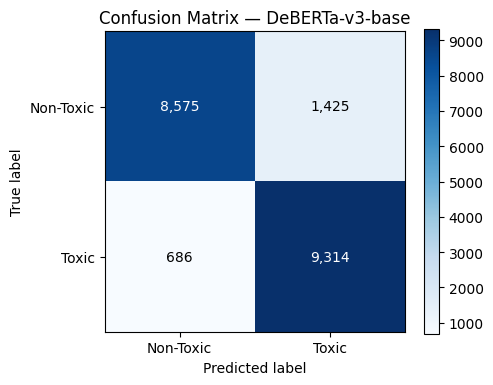

Saved: /kaggle/working/deberta_v3_base/figures/confusion_matrix.png


In [20]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")

classes = ["Non-Toxic", "Toxic"]
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix — DeBERTa-v3-base")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], ","), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.colorbar(im, ax=ax)
plt.tight_layout()

cm_path = FIGURE_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()

print(f"Saved: {cm_path}")


# ROC Curve


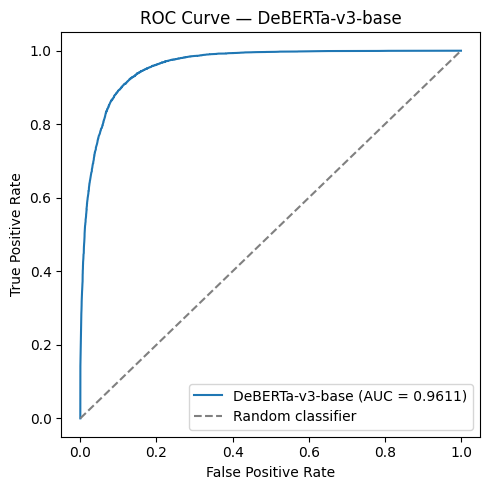

ROC-AUC: 0.9611
Saved: /kaggle/working/deberta_v3_base/figures/roc_curve.png


In [21]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f"DeBERTa-v3-base (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — DeBERTa-v3-base")
ax.legend(loc="lower right")
plt.tight_layout()

roc_path = FIGURE_DIR / "roc_curve.png"
plt.savefig(roc_path, dpi=150)
plt.show()

print(f"ROC-AUC: {auc:.4f}")
print(f"Saved: {roc_path}")


# Precision–Recall Curve


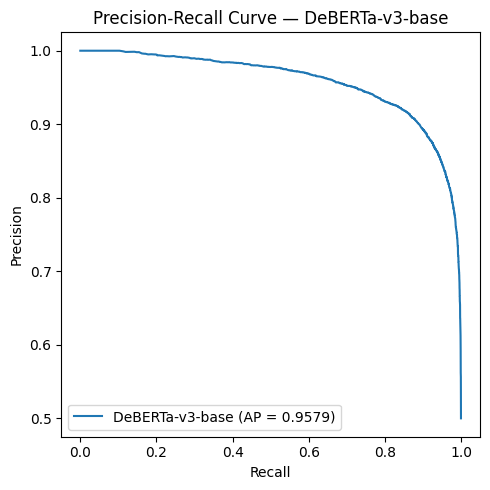

Average precision: 0.9579
Saved: /kaggle/working/deberta_v3_base/figures/precision_recall_curve.png


In [22]:
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
avg_precision = average_precision_score(y_true, y_prob)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(recall_vals, precision_vals, label=f"DeBERTa-v3-base (AP = {avg_precision:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — DeBERTa-v3-base")
ax.legend(loc="lower left")
plt.tight_layout()

pr_path = FIGURE_DIR / "precision_recall_curve.png"
plt.savefig(pr_path, dpi=150)
plt.show()

print(f"Average precision: {avg_precision:.4f}")
print(f"Saved: {pr_path}")


# Classification Report


In [23]:
report_text = classification_report(
    y_true, y_pred, target_names=["Non-Toxic", "Toxic"], digits=4,
)
report_dict = classification_report(
    y_true, y_pred, target_names=["Non-Toxic", "Toxic"], digits=4, output_dict=True,
)

print(report_text)

report_txt_path = REPORT_DIR / "classification_report.txt"
report_json_path = REPORT_DIR / "classification_report.json"

with open(report_txt_path, "w") as f:
    f.write(report_text)

with open(report_json_path, "w") as f:
    json.dump(report_dict, f, indent=2)

print(f"Saved: {report_txt_path}")
print(f"Saved: {report_json_path}")


              precision    recall  f1-score   support

   Non-Toxic     0.9259    0.8575    0.8904     10000
       Toxic     0.8673    0.9314    0.8982     10000

    accuracy                         0.8944     20000
   macro avg     0.8966    0.8944    0.8943     20000
weighted avg     0.8966    0.8944    0.8943     20000

Saved: /kaggle/working/deberta_v3_base/reports/classification_report.txt
Saved: /kaggle/working/deberta_v3_base/reports/classification_report.json


# Training History

The Trainer records loss and evaluation metrics after every logging/evaluation step in `trainer.state.log_history`. Saved as both a CSV and a figure.


Saved: /kaggle/working/deberta_v3_base/reports/training_history.csv


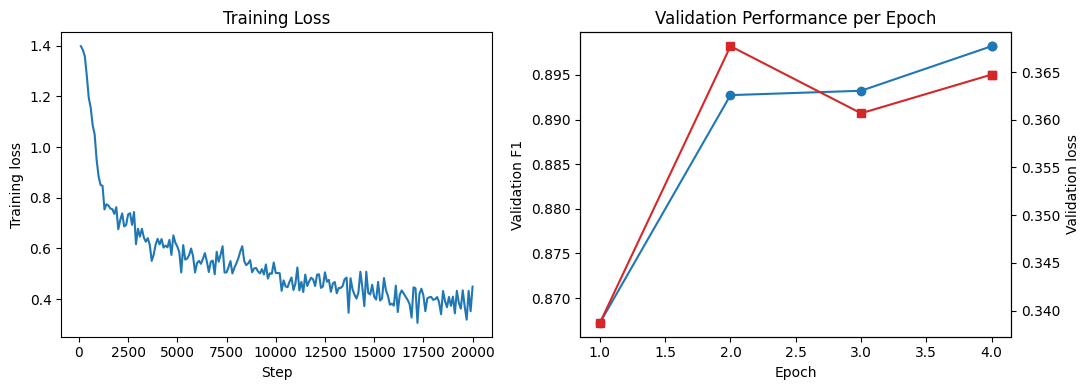

Saved: /kaggle/working/deberta_v3_base/figures/training_history.png


In [24]:
log_history = trainer.state.log_history
history_df = pd.DataFrame(log_history)

history_csv_path = REPORT_DIR / "training_history.csv"
history_df.to_csv(history_csv_path, index=False)
print(f"Saved: {history_csv_path}")

train_logs = history_df[history_df["loss"].notna()] if "loss" in history_df else pd.DataFrame()
if "eval_f1" in history_df.columns:
    eval_logs = history_df[history_df["eval_f1"].notna()].copy()
else:
    eval_logs = pd.DataFrame()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

if not train_logs.empty:
    axes[0].plot(train_logs["step"], train_logs["loss"], color="tab:blue")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Training loss")
axes[0].set_title("Training Loss")

if not eval_logs.empty:
    axes[1].plot(eval_logs["epoch"], eval_logs["eval_f1"], marker="o", label="Validation F1")
    if "eval_loss" in eval_logs:
        ax2 = axes[1].twinx()
        ax2.plot(eval_logs["epoch"], eval_logs["eval_loss"], marker="s", color="tab:red", label="Validation loss")
        ax2.set_ylabel("Validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation F1")
axes[1].set_title("Validation Performance per Epoch")

plt.tight_layout()

history_fig_path = FIGURE_DIR / "training_history.png"
plt.savefig(history_fig_path, dpi=150)
plt.show()

print(f"Saved: {history_fig_path}")


# Save Model, Tokenizer, Metrics, and Predictions

All final artifacts are written to `OUTPUT_DIR` and its subdirectories:

- Best model + tokenizer → `OUTPUT_DIR/best_model`
- Evaluation metrics → already saved to `REPORT_DIR/eval_metrics.json`
- Classification report → already saved to `REPORT_DIR`
- Figures (confusion matrix, ROC, PR curve, training history) → already saved to `FIGURE_DIR`
- Per-example predictions → `PREDICTION_DIR/validation_predictions.csv`


In [25]:
best_model_dir = OUTPUT_DIR / "best_model"
best_model_dir.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(best_model_dir))
tokenizer.save_pretrained(str(best_model_dir))

print(f"Model and tokenizer saved to: {best_model_dir}")

predictions_df = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred,
    "predicted_probability_toxic": y_prob,
})

predictions_path = PREDICTION_DIR / "validation_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)
print(f"Predictions saved to: {predictions_path}")

summary = {
    "model_name": MODEL_NAME,
    "training_examples": len(train_dataset),
    "validation_examples": len(valid_dataset),
    "epochs_configured": EPOCHS,
    "physical_batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "seed": SEED,
    "training_time_seconds": elapsed,
    "final_eval_metrics": eval_results,
}

summary_path = REPORT_DIR / "run_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2, default=str)

print(f"Run summary saved to: {summary_path}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: /kaggle/working/deberta_v3_base/best_model
Predictions saved to: /kaggle/working/deberta_v3_base/predictions/validation_predictions.csv
Run summary saved to: /kaggle/working/deberta_v3_base/reports/run_summary.json


# Summary

This notebook fine-tunes **microsoft/DeBERTa-v3-base** on the complete 80,000-example / 20,000-example balanced split produced by Notebook 03.

The Kaggle GPU configuration uses FP16 when CUDA is available, dynamic padding, GPU-aware batching, epoch-level evaluation/checkpointing, early stopping, and best-model selection using validation F1.

All evaluation artifacts are saved alongside the trained model:
- confusion matrix
- ROC curve
- Precision-Recall curve
- classification report
- training history
- validation predictions
- evaluation metrics
